Going from Raw Bronze data to the Silver Delta Table. Annotations, Cropping, and Validation Checks

In [0]:
# PySpark 
from pyspark.sql import functions as F, types as T
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

images_root = "/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/"    
ann_root    = "/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Annotation/"
out_path    = "/Volumes/dogdiffusion/default/diffusion_data/silver_delta"  # Delta table path

# 1) Read image binaries (distributed)
img_df = (
    spark.read.format("binaryFile")
    .option("recursiveFileLookup", "true")
    .load(images_root)
    .select(
        F.col("path"),
        F.col("content").alias("img_bytes"),
        F.lower(F.col("path")).alias("path_lc")
    )
    .where(
        (F.col("path_lc").endswith(".jpg")) |
        (F.col("path_lc").endswith(".jpeg")) |
        (F.col("path_lc").endswith(".png"))
    )
    .drop("path_lc")
)

# 2) Derive class/breed from folder name (parent folder)
# If paths look like .../Images/BREED/filename.jpg
img_df = img_df.withColumn("cls", F.element_at(F.split(F.col("path"), "/"), -2))

# 3) Compute matching xml path for each image
# Replace /Images/ -> /Annotation/ and extension -> .xml
img_df = (
    img_df
    .withColumn("xml_path",
        F.regexp_replace(F.col("path"), r"/Images/", "/Annotation/")
    )
    .withColumn("xml_path",
        F.regexp_replace(F.col("xml_path"), r"\.(jpg|jpeg|png)$", ".xml")
    )
)

# 4) Read XML text (whole files) into DataFrame
xml_df = (
    spark.read.format('binaryFile')
    .option('recursiveFileLookup', 'true')
    .load(ann_root)
    .withColumnRenamed('path', 'xml_path')
    .withColumn('xml_text', F.col('content').cast('string'))
    .select('xml_path', 'xml_text')
)

# 5) Parse bbox from XML text (returns nullable struct)
bbox_schema = T.StructType([
    T.StructField("xmin", T.IntegerType(), True),
    T.StructField("ymin", T.IntegerType(), True),
    T.StructField("xmax", T.IntegerType(), True),
    T.StructField("ymax", T.IntegerType(), True),
])

@F.udf(returnType=bbox_schema)
def parse_bbox(xml_text: str):
    if xml_text is None:
        return None
    try:
        import xml.etree.ElementTree as ET
        root = ET.fromstring(xml_text)
        obj = root.find("object")
        if obj is None:
            return None
        b = obj.find("bndbox")
        if b is None:
            return None
        xmin = int(b.findtext("xmin"))
        ymin = int(b.findtext("ymin"))
        xmax = int(b.findtext("xmax"))
        ymax = int(b.findtext("ymax"))
        if xmax <= xmin or ymax <= ymin:
            return None
        return (xmin, ymin, xmax, ymax)
    except Exception:
        return None

xml_df = xml_df.withColumn("bbox", parse_bbox(F.col("xml_text"))).drop("xml_text")

# 6) Join images with bbox (left join: bbox may be missing)
df = img_df.join(xml_df, on="xml_path", how="left")

# 7) Crop/resize/verify in distributed partitions with mapInPandas
out_schema = T.StructType([
    T.StructField("path", T.StringType(), False),
    T.StructField("cls", T.StringType(), False),
    T.StructField("label", T.IntegerType(), False),
    T.StructField("img_bytes_prepared", T.BinaryType(), False),
    T.StructField("width", T.IntegerType(), False),
    T.StructField("height", T.IntegerType(), False),
])

# Build stable label mapping (cls -> int) on driver
classes = [r["cls"] for r in df.select("cls").distinct().orderBy("cls").collect()]
cls_to_idx = {c: i for i, c in enumerate(classes)}

def preprocess_partition(pdf_iter):
    from io import BytesIO
    from PIL import Image

    # Access the mapping directly (no broadcast needed)
    mapping = cls_to_idx
    for pdf in pdf_iter:
        rows = []
        for row in pdf.itertuples(index=False):
            try:
                img = Image.open(BytesIO(row.img_bytes)).convert("RGB")

                # bbox crop if present
                if row.bbox is not None:
                    xmin, ymin, xmax, ymax = row.bbox
                    # clamp to image bounds
                    xmin = max(0, xmin); ymin = max(0, ymin)
                    xmax = min(img.size[0], xmax); ymax = min(img.size[1], ymax)
                    if xmax > xmin and ymax > ymin:
                        img = img.crop((xmin, ymin, xmax, ymax))

                # safety resize
                target = (64, 64)
                if img.size[0] < 32 or img.size[1] < 32:
                    img = img.resize(target)
                else:
                    img = img.resize(target)

                # encode to PNG bytes (or JPEG)
                buf = BytesIO()
                img.save(buf, format="PNG")
                out_bytes = buf.getvalue()

                rows.append((
                    row.path,
                    row.cls,
                    int(mapping[row.cls]),
                    out_bytes,
                    target[0],
                    target[1],
                ))
            except Exception:
                # corrupted/unreadable image -> skip
                continue

        import pandas as pd
        yield pd.DataFrame(rows, columns=[
            "path", "cls", "label", "img_bytes_prepared", "width", "height"
        ])

prepared_df = df.mapInPandas(preprocess_partition, schema=out_schema)

# 8) Write prepared dataset as Delta table
(prepared_df
 .repartition(200)  # tune
 .write
 .format("delta")
 .mode("overwrite")
 .save(out_path)
)

print("Classes:", classes)
print("Wrote Delta table to:", out_path)

Classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n02094433-Yo

In [0]:
# Show the Delta Lake transaction log for the silver_delta table
from delta.tables import DeltaTable

delta_path = "/Volumes/dogdiffusion/default/diffusion_data/silver_delta"
dt = DeltaTable.forPath(spark, delta_path)

# Display Delta table history (transaction log)
display(dt.history())

version,timestamp,userId,userName,operation,operationParameters,job,notebook,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-02-11T21:42:44.000Z,147333505194466,chiemekanwakama@gmail.com,WRITE,"Map(mode -> Overwrite, statsOnLoad -> false, partitionBy -> [])",null,List(3110885712037015),0211-213257-hdxx4wy7-v2n,null,WriteSerializable,false,"Map(numFiles -> 200, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 20580, numOutputBytes -> 178475865)",null,Databricks-Runtime/17.3.x-photon-scala2.13


In [0]:
# Read and display the Delta table
out_path = "/Volumes/dogdiffusion/default/diffusion_data/silver_delta"
df = spark.read.format("delta").load(out_path)
display(df)

path cls label img_bytes_prepared width height dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02089973-English_foxhound/n02089973_2045.jpg n02089973-English_foxhound 16 iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAIAAAAlC+aJAAAKMGlDQ1BJQ0MgUHJvZmlsZQAAeJydlndUVNcWh8+9d3qhzTAUKUPvvQ0gvTep0kRhmBlgKAMOMzSxIaICEUVEBBVBgiIGjIYisSKKhYBgwR6QIKDEYBRRUXkzslZ05eW9l5ffH2d9a5+99z1n733WugCQvP25vHRYCoA0noAf4uVKj4yKpmP7AQzwAAPMAGCyMjMCQj3DgEg+Hm70TJET+CIIgDd3xCsAN428g+h08P9JmpXBF4jSBInYgs3JZIm4UMSp2YIMsX1GxNT4FDHDKDHzRQcUsbyYExfZ8LPPIjuLmZ3GY4tYfOYMdhpbzD0i3pol5IgY8RdxURaXky3iWyLWTBWmcUX8VhybxmFmAoAiie0CDitJxKYiJvHDQtxEvBQAHCnxK47/igWcHIH4Um7pGbl8bmKSgK7L0qOb2doy6N6c7FSOQGAUxGSlMPlsult6WgaTlwvA4p0/S0ZcW7qoyNZmttbWRubGZl8V6r9u/k2Je7tIr4I/9wyi9X2x/ZVfej0AjFlRbXZ8scXvBaBjMwDy97/YNA8CICnqW/vAV/ehieclSSDIsDMxyc7ONuZyWMbigv6h/+nwN/TV94zF6f4oD92dk8AUpgro4rqx0lPThXx6ZgaTxaEb/XmI/3HgX5/DMISTwOFzeKKIcNGUcXmJonbz2FwBN51H5/L+UxP/YdiftDjXIlEaPgFqrDGQGqAC5Nc+gKIQARJzQLQD/dE3f3w4EL+8CNWJxbn/LOjfs8Jl4iWTm/g5zi0kjM4S8rMW98TPEqABAUgCKlAAKkAD6AIjYA5sgD1wBh7AFwSCMBAFVgEWSAJpgA+yQT7YCIpACdgBdoNqUAsaQBNoASdABzgNLoDL4Dq4AW6DB2AEjIPnYAa8AfMQBGEhMkSBFCBVSAsygMwhBuQIeUD+UAgUBcVBiRAPEkL50CaoBCqHqqE6qAn6HjoFXYCuQoPQPWgUmoJ+h97DCEyCqbAyrA2bwAzYBfaDw+CVcCK8Gs6DC+HtcBVcDx+D2+EL8HX4NjwCP4dnEYAQERqihhghDMQNCUSikQSEj6xDipFKpB5pQbqQXuQmMoJMI+9QGBQFRUcZoexR3qjlKBZqNWodqhRVjTqCakf1oG6iRlEzqE9oMloJbYC2Q/ugI9GJ6Gx0EboS3YhuQ19C30aPo99gMBgaRgdjg/HGRGGSMWswpZj9mFbMecwgZgwzi8ViFbAGWAdsIJaJFWCLsHuxx7DnsEPYcexbHBGnijPHeeKicTxcAa4SdxR3FjeEm8DN46XwWng7fCCejc/Fl+Eb8F34Afw4fp4gTdAhOBDCCMmEjYQqQgvhEuEh4RWRSFQn2hKDiVziBmIV8TjxCnGU+I4kQ9InuZFiSELSdtJh0nnSPdIrMpmsTXYmR5MF5O3kJvJF8mPyWwmKhLGEjwRbYr1EjUS7xJDEC0m8pJaki+QqyTzJSsmTkgOS01J4KW0pNymm1DqpGqlTUsNSs9IUaTPpQOk06VLpo9JXpSdlsDLaMh4ybJlCmUMyF2XGKAhFg+JGYVE2URoolyjjVAxVh+pDTaaWUL+j9lNnZGVkLWXDZXNka2TPyI7QEJo2zYeWSiujnaDdob2XU5ZzkePIbZNrkRuSm5NfIu8sz5Evlm+Vvy3/XoGu4KGQorBToUPhkSJKUV8xWDFb8YDiJcXpJdQl9ktYS4qXnFhyXwlW0lcKUVqjdEipT2lWWUXZSzlDea/yReVpFZqKs0qySoXKWZUpVYqqoypXtUL1nOozuizdhZ5Kr6L30GfUlNS81YRqdWr9avPqOurL1QvUW9UfaRA0GBoJGhUa3RozmqqaAZr5ms2a97XwWgytJK09Wr1ac9o62hHaW7Q7tCd15HV8dPJ0mnUe6pJ1nXRX69br3tLD6DH0UvT2693Qh/Wt9JP0a/QHDGADawOuwX6DQUO0oa0hz7DecNiIZORilGXUbDRqTDP2Ny4w7jB+YaJpEm2y06TX5JOplWmqaYPpAzMZM1+zArMus9/N9c1Z5jXmtyzIFp4W6y06LV5aGlhyLA9Y3rWiWAVYbbHqtvpobWPNt26xnrLRtImz2WczzKAyghiljCu2aFtX2/W2p23f2VnbCexO2P1mb2SfYn/UfnKpzlLO0oalYw7qDkyHOocRR7pjnONBxxEnNSemU73TE2cNZ7Zzo/OEi55Lsssxlxeupq581zbXOTc7t7Vu590Rdy/3Yvd+DxmP5R7VHo891T0TPZs9Z7ysvNZ4nfdGe/t57/Qe9lH2Yfk0+cz42viu9e3xI/mF+lX7PfHX9+f7dwXAAb4BuwIeLtNaxlvWEQgCfQJ3BT4K0glaHfRjMCY4KLgm+GmIWUh+SG8oJTQ29GjomzDXsLKwB8t1lwuXd4dLhseEN4XPRbhHlEeMRJpEro28HqUYxY3qjMZGh0c3Rs+u8Fixe8V4jFVMUcydlTorc1ZeXaW4KnXVmVjJWGbsyTh0XETc0bgPzEBmPXM23id+X/wMy421h/Wc7cyuYE9xHDjlnIkEh4TyhMlEh8RdiVNJTkmVSdNcN24192Wyd3Jt8lxKYMrhlIXUiNTWNFxaXNopngwvhdeTrpKekz6YYZBRlDGy2m717tUzfD9+YyaUuTKzU0AV/Uz1CXWFm4WjWY5ZNVlvs8OzT+ZI5/By+nL1c7flTuR55n27BrWGtaY7Xy1/Y/7oWpe1deugdfHrutdrrC9cP77Ba8ORjYSNKRt/KjAtKC94vSliU1ehcuGGwrHNXpubiySK+EXDW+y31G5FbeVu7d9msW3vtk/F7OJrJaYllSUfSlml174x+6bqm4XtCdv7y6zLDuzA7ODtuLPTaeeRcunyvPKxXQG72ivoFcUVr3fH7r5aaVlZu4ewR7hnpMq/qnOv5t4dez9UJ1XfrnGtad2ntG/bvrn97P1DB5wPtNQq15bUvj/IPXi3zquuvV67vvIQ5lDWoacN4Q293zK+bWpUbCxp/HiYd3jkSMiRniabpqajSkfLmuFmYfPUsZhjN75z/66zxailrpXWWnIcHBcef/Z93Pd3Tvid6D7JONnyg9YP+9oobcXtUHtu+0xHUsdIZ1Tn4CnfU91d9l1tPxr/ePi02umaM7Jnys4SzhaeXTiXd272fMb56QuJF8a6Y7sfXIy8eKsnuKf/kt+lK5c9L1/sdek9d8XhyumrdldPXWNc67hufb29z6qv7Sern9r6rfvbB2wGOm/Y3ugaXDp4dshp6MJN95uXb/ncun572e3BO8vv3B2OGR65y747eS/13sv7WffnH2x4iH5Y/EjqUeVjpcf1P+v93DpiPXJm1H2070nokwdjrLHnv2T+8mG88Cn5aeWE6kTTpPnk6SnPqRvPVjwbf57xfH666FfpX/e90H3xw2/Ov/XNRM6Mv+S/XPi99JXCq8OvLV93zwbNPn6T9mZ+rvitwtsj7xjvet9HvJ+Yz/6A/VD1Ue9j1ye/Tw8X0hYW/gUDmPP8uaxzGQAAJGpJREFUeJw1uemv5vd53nff3/W3PevZ58zGmeFwuEsUSVHRvsuxHDtKLDkNGjQtFLlBEhhJirxw2qLumzZp+qIIYMRo4ziKHcDOJsdxFDuV5NoSRYo0Kc4MZ1/OmTNnffbnt33Xuy/UXn/DhQv4fC7829/4hdo0uts9mhwpzl85d/76wXHm/SBp3jouTdXdTAQlFoX0jkePxs3TDMg

In [0]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from io import BytesIO
import pandas as pd

class DeltaImageDataset(Dataset):
    """
    PyTorch Dataset that reads preprocessed images from Delta table.
    Compatible with your existing DDPM training pipeline.
    """
    def __init__(self, delta_path, transform=None, mode="RGB"):
        """
        Args:
            delta_path: Path to delta table
            transform: torchvision transforms to apply
            mode: Image mode ("RGB" or "L")
        """
        self.transform = transform
        self.mode = mode
        
        print(f"\nLoading dataset from: {delta_path}")
        
        # Load delta into pandas (efficient for this size)
        self.data = spark.read.format("delta").load(delta_path).toPandas()
        
        # Extract unique classes and create mapping
        self.classes = sorted(self.data['cls'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        print(f"✓ Loaded {len(self.data)} samples")
        print(f"✓ Number of classes: {len(self.classes)}")
        print(f"✓ Average per class: {len(self.data) / len(self.classes):.1f}")
        
        # Verify labels match
        assert all(self.data['label'] == self.data['cls'].map(self.class_to_idx)), \
            "Label mismatch detected!"
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        try:
            # Decode image from bytes (already preprocessed: cropped + resized to 64x64)
            img_bytes = row['img_bytes_prepared']
            image = Image.open(BytesIO(img_bytes)).convert(self.mode)
            
            # Apply transforms (augmentation + normalization)
            if self.transform:
                image = self.transform(image)
            
            label = row['label']
            
            return image, label
            
        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            # Return next valid sample
            return self.__getitem__((idx + 1) % len(self.data))


def create_delta_dataloader(delta_path, batch_size, **kwargs):
    """
    Creates a DataLoader from delta dataset.
    Compatible with your config.yml settings.
    
    Args:
        delta_path: Path to delta table
        batch_size: Batch size
        kwargs: Same as original (mode, image_size, shuffle, etc.)
    """
    mode = kwargs.get("mode", "RGB")
    norm = (0.5,) if mode == "L" else (0.5, 0.5, 0.5)
    
    # Handle image_size (should match preprocessed size: 64x64)
    image_size = kwargs.get("image_size", 64)
    if isinstance(image_size, int):
        image_size = (image_size, image_size)
    
    print(f"\n{'='*50}")
    print(f"Delta Dataset Configuration")
    print(f"{'='*50}")
    print(f"Delta path: {delta_path}")
    print(f"Target size: {image_size}")
    print(f"Batch size: {batch_size}")
    print(f"Mode: {mode}")
    
    # Data augmentation transforms
    # Images are already 64x64, so we resize to target if different
    trans = transforms.Compose([
        transforms.Resize(image_size),  # Resize if config specifies different size
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(norm, norm)
    ])
    
    dataset = DeltaImageDataset(
        delta_path=delta_path,
        transform=trans,
        mode=mode
    )
    
    print(f"{'='*50}\n")
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=kwargs.get("shuffle", True),
        drop_last=kwargs.get("drop_last", True),
        pin_memory=kwargs.get("pin_memory", True),
        num_workers=kwargs.get("num_workers", 2)
    )

Preview of Dataset: Dog images, Class number, batch size, sample total


Delta Dataset Configuration
Delta path: /Volumes/dogdiffusion/default/diffusion_data/silver_delta
Target size: (128, 128)
Batch size: 16
Mode: RGB

Loading dataset from: /Volumes/dogdiffusion/default/diffusion_data/silver_delta
✓ Loaded 20580 samples
✓ Number of classes: 120
✓ Average per class: 171.5


✓ DataLoader ready!
  Batches per epoch: 1286
  Total samples: 20580
  Classes: 120


/local_disk0/.ephemeral_nfs/envs/pythonEnv-b6e639f9-db86-406b-9c76-e48486051b58/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✓ Batch loaded successfully!
  Image batch shape: torch.Size([16, 3, 128, 128])
  Label batch shape: torch.Size([16])
  Image range: [-1.00, 1.00]
  Sample labels: [81, 17, 73, 108, 101]


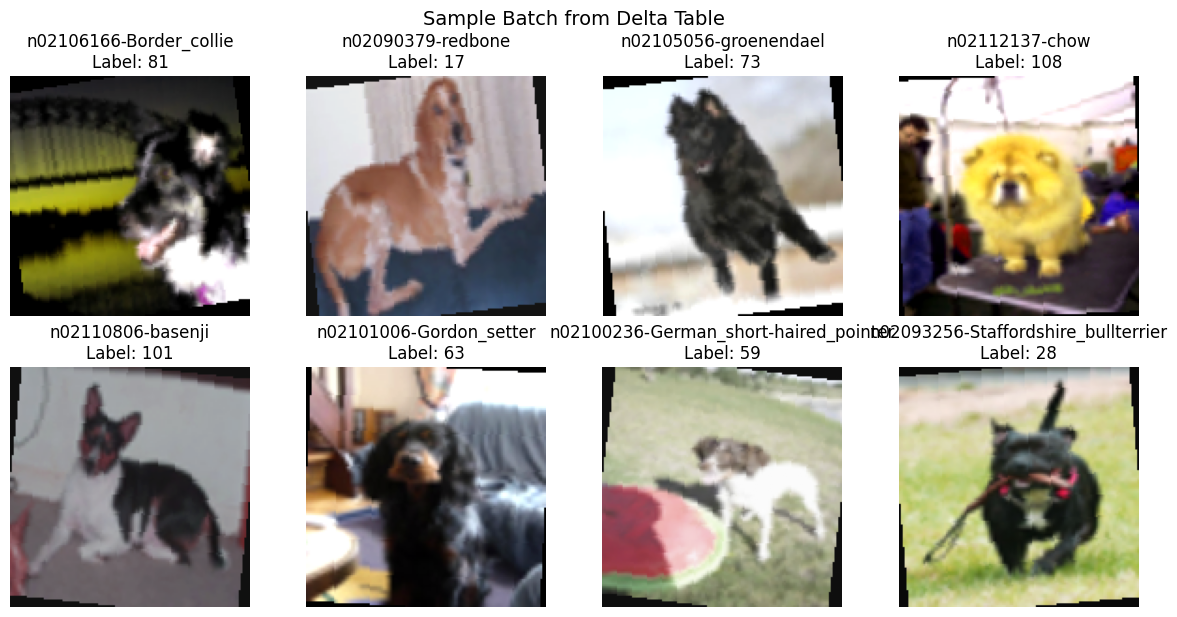


✓ Visualization complete!


In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Create Delta DataLoader
delta_path = "/Volumes/dogdiffusion/default/diffusion_data/silver_delta"

test_loader = create_delta_dataloader(
    delta_path=delta_path,
    batch_size=16,
    mode="RGB",
    image_size=128,  # Your config uses 128
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    num_workers=2
)

print(f"\n✓ DataLoader ready!")
print(f"  Batches per epoch: {len(test_loader)}")
print(f"  Total samples: {len(test_loader.dataset)}")
print(f"  Classes: {len(test_loader.dataset.classes)}")

# Test loading one batch
images, labels = next(iter(test_loader))
print(f"\n✓ Batch loaded successfully!")
print(f"  Image batch shape: {images.shape}")
print(f"  Label batch shape: {labels.shape}")
print(f"  Image range: [{images.min():.2f}, {images.max():.2f}]")
print(f"  Sample labels: {labels[:5].tolist()}")

# Denormalize for visualization
images_np = images.permute(0, 2, 3, 1).cpu().numpy()
images_np = (images_np * 0.5 + 0.5).clip(0, 1)

# Plot first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(images_np[i])
    class_name = test_loader.dataset.classes[labels[i]]
    axes[i].set_title(f"{class_name}\nLabel: {labels[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Sample Batch from Delta Table', y=1.02, fontsize=14)
plt.show()

print("\n✓ Visualization complete!")

Verifying that Delta Table is ready for use in training

In [0]:
# Verify the Delta table is ready to use

delta_path = "/Volumes/dogdiffusion/default/diffusion_data/silver_delta"

print("Delta Table Verification")
print("="*60)

# Read Delta table
df = spark.read.format("delta").load(delta_path)

print(f"\n✓ Total records: {df.count():,}")
print(f"✓ Number of classes: {df.select('cls').distinct().count()}")

# Show schema
print("\nSchema:")
df.printSchema()

# Show class distribution
print("\nClass distribution:")
class_dist = df.groupBy("cls", "label").count().orderBy("label")
display(class_dist)

# Show sample records
print("\nSample records:")
display(df.select("path", "cls", "label", "width", "height").limit(10))

Delta Table Verification

✓ Total records: 20,580
✓ Number of classes: 120

Schema:
root
 |-- path: string (nullable = true)
 |-- cls: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- img_bytes_prepared: binary (nullable = true)
 |-- width: integer (nullable = true)
 |-- height: integer (nullable = true)


Class distribution:


cls,label,count
n02085620-Chihuahua,0,152
n02085782-Japanese_spaniel,1,185
n02085936-Maltese_dog,2,252
n02086079-Pekinese,3,149
n02086240-Shih-Tzu,4,214
n02086646-Blenheim_spaniel,5,188
n02086910-papillon,6,196
n02087046-toy_terrier,7,172
n02087394-Rhodesian_ridgeback,8,172
n02088094-Afghan_hound,9,239



Sample records:


path,cls,label,width,height
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02088094-Afghan_hound/n02088094_3531.jpg,n02088094-Afghan_hound,9,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02105641-Old_English_sheepdog/n02105641_678.jpg,n02105641-Old_English_sheepdog,78,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02085782-Japanese_spaniel/n02085782_2250.jpg,n02085782-Japanese_spaniel,1,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02106382-Bouvier_des_Flandres/n02106382_1806.jpg,n02106382-Bouvier_des_Flandres,82,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02100735-English_setter/n02100735_3899.jpg,n02100735-English_setter,61,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02115913-dhole/n02115913_3601.jpg,n02115913-dhole,118,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02097298-Scotch_terrier/n02097298_8101.jpg,n02097298-Scotch_terrier,48,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02115641-dingo/n02115641_266.jpg,n02115641-dingo,117,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02113978-Mexican_hairless/n02113978_1746.jpg,n02113978-Mexican_hairless,116,64,64
dbfs:/Volumes/dogdiffusion/default/diffusion_data/Mixed-Breed-Dog-Diffusion-Network-main/DDPM/data/Training Images (Stanford)/n02097298-Scotch_terrier/n02097298_9085.jpg,n02097298-Scotch_terrier,48,64,64
